<a href="https://colab.research.google.com/github/pui-ying-png/AI_Impact_on_Jobs_2030/blob/main/AI_Impact_in_future_on_jobs_market_in_2030.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/AI_Impact_on_Jobs_2030.csv')

In [4]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/AI_Impact_on_Jobs_2030.csv')

In [5]:
df.head()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              3000 non-null   object 
 1   Job_Title                3000 non-null   object 
 2   Industry                 3000 non-null   object 
 3   Country                  3000 non-null   object 
 4   Education_Level          3000 non-null   object 
 5   Years_Experience         3000 non-null   int64  
 6   AI_Replacement_Risk      3000 non-null   float64
 7   Future_Demand_Score      3000 non-null   float64
 8   Remote_Work_Possibility  3000 non-null   object 
 9   Average_Salary_USD       3000 non-null   int64  
 10  Required_Skills          3000 non-null   object 
 11  Automation_Level         3000 non-null   object 
 12  Job_Growth_2030          3000 non-null   int64  
 13  Work_Hours_Per_Week      3000 non-null   int64  
 14  Company_Size            

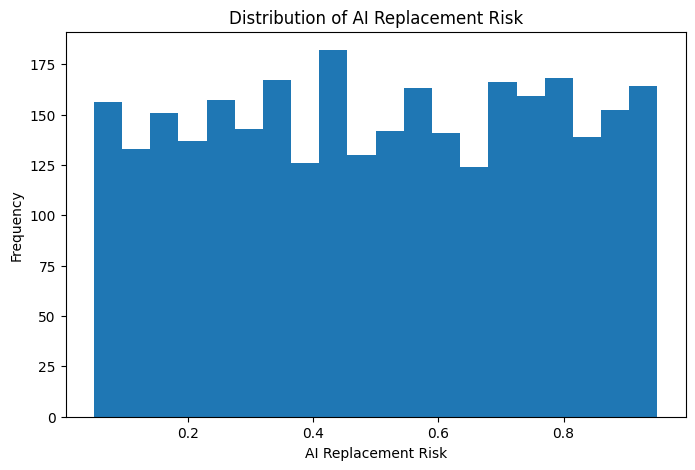

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['AI_Replacement_Risk'], bins=20)
plt.title('Distribution of AI Replacement Risk')
plt.xlabel('AI Replacement Risk')
plt.ylabel('Frequency')
plt.show()

In [8]:
# Select numerical columns only
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
correlation_matrix = numeric_df.corr()

print(correlation_matrix)

                     Years_Experience  AI_Replacement_Risk  \
Years_Experience             1.000000            -0.033668   
AI_Replacement_Risk         -0.033668             1.000000   
Future_Demand_Score         -0.047494             0.007761   
Average_Salary_USD           0.012795            -0.006714   
Job_Growth_2030             -0.023781             0.004887   
Work_Hours_Per_Week         -0.010387             0.001582   
Performance_Score            0.023758            -0.012806   
Job_Satisfaction             0.018071             0.016181   

                     Future_Demand_Score  Average_Salary_USD  Job_Growth_2030  \
Years_Experience               -0.047494            0.012795        -0.023781   
AI_Replacement_Risk             0.007761           -0.006714         0.004887   
Future_Demand_Score             1.000000            0.005162         0.054455   
Average_Salary_USD              0.005162            1.000000        -0.011723   
Job_Growth_2030                 0.05

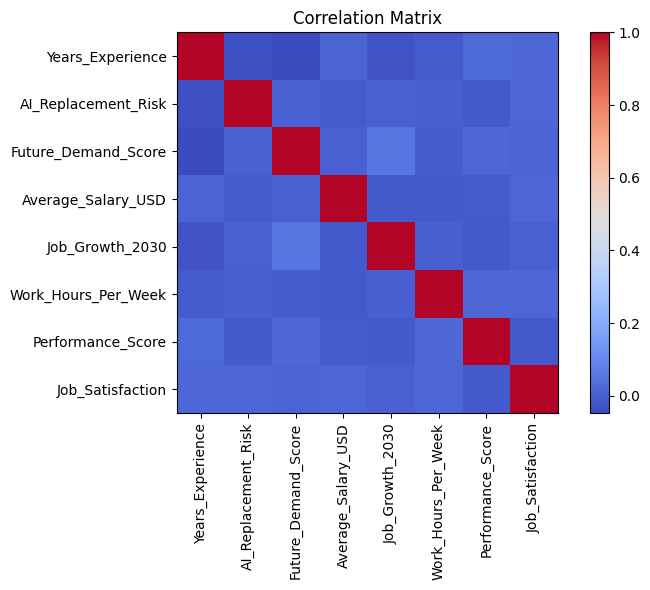

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

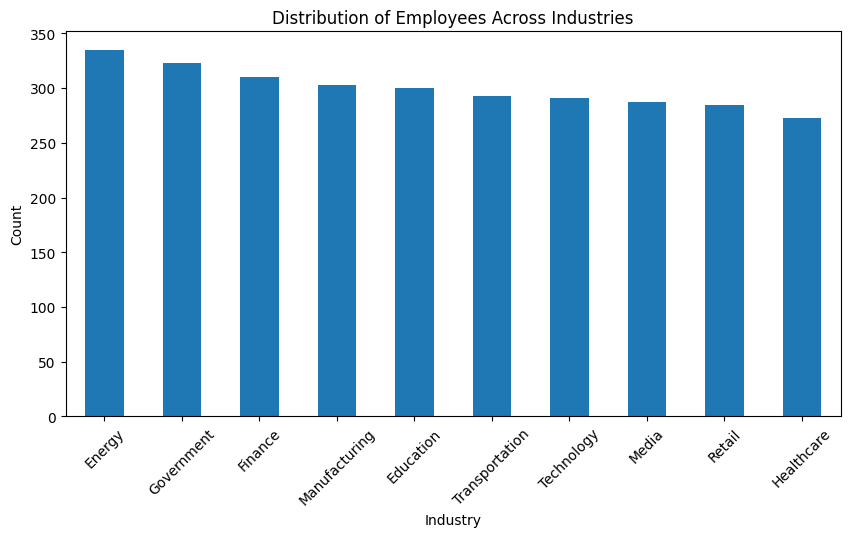

In [10]:
import matplotlib.pyplot as plt

industry_counts = df['Industry'].value_counts()

plt.figure(figsize=(10,5))
industry_counts.plot(kind='bar')
plt.title('Distribution of Employees Across Industries')
plt.xlabel('Industry')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [65]:
df.isnull().sum()

,0
Employee_ID,0
Job_Title,0
Industry,0
Country,0
Education_Level,0
Years_Experience,0
AI_Replacement_Risk,0
Future_Demand_Score,0
Remote_Work_Possibility,0
Average_Salary_USD,0


In [66]:
Q1 = df['Average_Salary_USD'].quantile(0.25)
Q3 = df['Average_Salary_USD'].quantile(0.75)
IQR = Q3 - Q1


outliers = df[(df['Average_Salary_USD'] < Q1 - 1.5*IQR) |
             (df['Average_Salary_USD'] > Q3 + 1.5*IQR)]


print("Number of outliers:", len(outliers))

Number of outliers: 0


In [67]:
outliers.head()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026


In [68]:
from sklearn.preprocessing import LabelEncoder


# Create encoder
label_encoder = LabelEncoder()


# List of categorical columns
categorical_columns = [
   'Job_Title',
   'Industry',
   'Country',
   'Education_Level',
   'Remote_Work_Possibility',
   'Required_Skills',
   'Automation_Level',
   'Company_Size',
   'AI_Tool_Usage',
   'Upskilling_Needed',
   'Hiring_Trend_2026'
]


# Encode each categorical column
for column in categorical_columns:
   df[column] = label_encoder.fit_transform(df[column])


# Display results
df.head()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,5,4,4,3,-1.512148,0.25,0.788916,2,1.457696,2464,1,-0.877414,-0.870964,0,0,-1.642917,1,0.727495,1
1,AIJ-100001,11,7,8,0,1.543233,0.73,-1.196647,1,0.255313,992,1,-1.370400,-0.310738,2,2,1.174213,0,1.050309,1
2,AIJ-100002,10,0,1,1,1.144705,0.80,0.391803,2,-0.033247,1454,2,-1.370400,1.369938,2,1,-0.429032,0,0.448305,2
3,AIJ-100003,4,3,8,0,-0.980777,0.29,1.494894,1,1.322054,1360,2,-0.630920,1.594028,0,0,0.177911,0,1.172455,0
4,AIJ-100004,11,0,7,3,1.011862,0.11,1.406647,1,0.939426,2685,1,-0.692544,-1.207099,2,0,0.189362,0,0.840916,2


In [69]:
from sklearn.preprocessing import StandardScaler


# Select numerical columns
numerical_columns = [
   'Years_Experience',
   'Future_Demand_Score',
   'Average_Salary_USD',
   'Job_Growth_2030',
   'Work_Hours_Per_Week',
   'Performance_Score',
   'Job_Satisfaction'
]


# Create scaler
scaler = StandardScaler()


# Scale the variables
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])


# Display results
df.head()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,5,4,4,3,-1.512148,0.25,0.788916,2,1.457696,2464,1,-0.877414,-0.870964,0,0,-1.642917,1,0.727495,1
1,AIJ-100001,11,7,8,0,1.543233,0.73,-1.196647,1,0.255313,992,1,-1.370400,-0.310738,2,2,1.174213,0,1.050309,1
2,AIJ-100002,10,0,1,1,1.144705,0.80,0.391803,2,-0.033247,1454,2,-1.370400,1.369938,2,1,-0.429032,0,0.448305,2
3,AIJ-100003,4,3,8,0,-0.980777,0.29,1.494894,1,1.322054,1360,2,-0.630920,1.594028,0,0,0.177911,0,1.172455,0
4,AIJ-100004,11,0,7,3,1.011862,0.11,1.406647,1,0.939426,2685,1,-0.692544,-1.207099,2,0,0.189362,0,0.840916,2


In [70]:
from sklearn.model_selection import train_test_split


# Features (X)
X = df.drop(columns=['Employee_ID', 'AI_Replacement_Risk'])


# Target (y)
y = df['AI_Replacement_Risk']


# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
   X, y,
   test_size=0.2,
   random_state=42
)


print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (2400, 18)
Testing samples: (600, 18)


In [71]:
from sklearn.linear_model import LinearRegression


# Create model
model = LinearRegression()


# Train model
model.fit(X_train, y_train)


print("Baseline model trained successfully.")

Baseline model trained successfully.


In [72]:
# Predict on test set
y_pred = model.predict(X_test)


print(y_pred[:10])

[0.5152017  0.51097926 0.4971688  0.50819787 0.50014261 0.51915042
 0.49475002 0.47950049 0.50363161 0.49836135]


In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.2258062579335415
Mean Squared Error (MSE): 0.06765166081469685
Root Mean Squared Error (RMSE): 0.26009932874710934
R² Score: -0.0028510177973877227


In [74]:
from sklearn.ensemble import RandomForestRegressor


# Create the improved model
rf_model = RandomForestRegressor(
   n_estimators=100,
   random_state=42
)


# Train the model
rf_model.fit(X_train, y_train)


print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [75]:
rf_predictions = rf_model.predict(X_test)


print(rf_predictions[:10])

[0.4537 0.5067 0.5391 0.598  0.5558 0.4802 0.5253 0.4976 0.4696 0.5567]


In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


mae = mean_absolute_error(y_test, rf_predictions)
mse = mean_squared_error(y_test, rf_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_predictions)


print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.228623
Mean Squared Error (MSE): 0.0692499716
Root Mean Squared Error (RMSE): 0.2631538933780004
R² Score: -0.026543970468397404
